In [1]:
# Import necessary libraries
from sklearn import datasets
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load and Prepare the Data
iris = datasets.load_iris()
X = iris.data[: , (2, 3)] # Petal length and width
y = (iris.target == 0) | (iris.target == 1) # Only setosa and versicolor

In [3]:
# Train a linear SVM Classifier
svm_clf = SVC(kernel = "linear", C = 1e10)
svm_clf.fit(X[y], iris.target[y])

SVC(C=10000000000.0, kernel='linear')

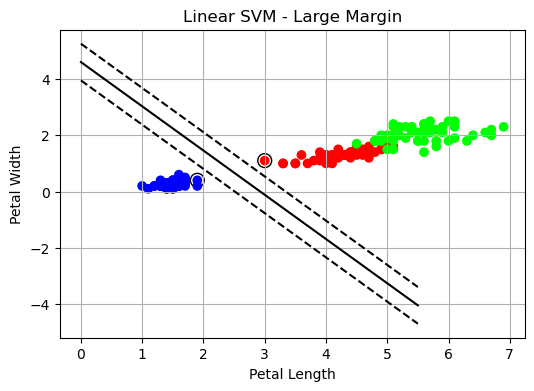

In [4]:
# Plot Decision Boundary
def plot_svc_decision_boundary(clf, xmin, xmax):
    w = clf.coef_[0]
    b = clf.intercept_[0]
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0] / w[1] * x0 - b / w[1]
    margin = 1 / np.linalg.norm(w)
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
    support_vectors = clf.support_vectors_
    plt.plot(x0, decision_boundary, "k-")
    plt.plot(x0, gutter_up, "k--")
    plt.plot(x0, gutter_down, "k--")
    plt.scatter(support_vectors[:, 0], support_vectors[:, 1],
                s=100, facecolors='none', edgecolors='k')

plt.figure(figsize = (6, 4))
plot_svc_decision_boundary(svm_clf, 0, 5.5)
plt.scatter(X[:, 0], X[:, 1], c = iris.target, cmap = plt.cm.brg)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.grid()
plt.title("Linear SVM - Large Margin")
plt.show()